In [5]:
# Standard Python modules 
import os, sys 
import glob 
import numpy as np 
import pandas as pd 
import xarray as xr 
import re 
from datetime import datetime, timedelta 

path_to_data = '/cw3e/mead/projects/cwp162/data/' 
path_to_out = '../out/' # output files (numerical results, intermediate datafiles) -- read & write 
path_to_figs = '../figs/' # figures 

## Load tARgetv4 AR data 
fname = path_to_data + 'downloads/globalARcatalog_ERA5_1940-2024_v4.0.nc' 
ds = xr.open_dataset(fname) 
ds = ds.isel(lev=0, ens=0).squeeze() 
## load in ARID list for HUC8 
ARID = 200812241803
# Convert to string for safe slicing 
ARID_str = str(ARID).zfill(12) 
# Parse date portion (YYYYMMDDHH) 
dt = datetime.strptime(ARID_str[:10], "%Y%m%d%H") 
# Extract last two digits as ID 
ID = int(ARID_str[-2:]) 
# Optional: formatted date string 
date_str = dt.strftime("%Y-%m-%d %H:%M") 
print(dt) # datetime object 
print(date_str) 
# formatted string 
print(ID) # integer 0–99 
tmp = ds.sel(time=date_str) 
## landfall lat and lon - one lat/lon per ARID 
lflat = tmp.lflat.isel(lat=ID-1).values 
lflon = tmp.lflon.isel(lat=ID-1).values 
lfivtx = tmp.lfivtx.isel(lat=ID-1).values 
lfivty = tmp.lfivty.isel(lat=ID-1).values 
lfivtdir = tmp.lfivtdir.isel(lat=ID-1).values 
print(lflat, lflon, lfivtx, lfivty, lfivtdir) 
## get date 14 days after AR starts 
## probably the lifetime of the AR does not extend past this 
dt2 = dt + timedelta(hours=14*24) 
date_str2 = dt2.strftime("%Y-%m-%d %H:%M") 
## slice to start date and 14 days after start date 
tmp2 = ds.sel(time=slice(date_str, date_str2)) 

# find maximum date of ARID 
date_ds = tmp2.kidmap.where(tmp2.kidmap == ARID, drop=True) 
max_date = date_ds.time.values[-1] 
print(max_date) 
## pull the "trajectory" of the AR during it's lifetime 
date_lst = date_ds.time.values 
hlat_lst = [] 
hlon_lst = [] 
for date in date_lst: 
    tmp3 = ds.sel(time=date) 
    ## find new ID from ds.shapemap 
    ## the ID changes every time step 
    new_ID = int(tmp3.shapemap.where(tmp3.kidmap==ARID).max().values) 
    ## for each time step the ARID is present, what is the head lat and head lon? 
    hlat = tmp3.hlat.isel(lat=new_ID-1).values 
    hlon = tmp3.hlon.isel(lat=new_ID-1).values 
    hlat_lst.append(hlat) 
    hlon_lst.append(hlon) 
    print(hlat, hlon)

2008-12-24 18:00:00
2008-12-24 18:00
3
34.75 239.25 -7.9648438 324.66943 358.5947
2008-12-30T00:00:00.000000000
38.5 235.25
38.0 236.5
37.5 261.0
39.0 263.5
40.25 266.0
42.75 270.5
45.5 272.75
45.0 277.25
37.75 282.75
40.0 284.5
45.0 288.0
43.5 290.75
44.0 294.0
42.0 295.5
45.25 297.5
39.25 300.0
55.5 303.0
42.5 301.25
42.5 303.5
62.0 279.25
62.0 275.5
62.0 275.0


In [2]:
import xarray as xr
import pandas as pd
import numpy as np
import sys, os

import geopandas as gpd
from shapely.geometry import Point, LineString

import cartopy
import matplotlib.pyplot as plt
import cmocean.cm as cmo
from matplotlib.gridspec import GridSpec

# cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature

sys.path.append('modules')
from plotter import draw_basemap, plot_terrain
import customcmaps as ccmap

path_to_data = '/cw3e/mead/projects/cwp162/data/'
path_to_out  = '../out/'       # output files (numerical results, intermediate datafiles) -- read & write
path_to_figs = 'figs/'      # figures

traj_df = pd.read_parquet("out/traj_all.parquet")
traj_df = traj_df.dropna(subset=["clat", "clon", "time"])

gdf_points = gpd.GeoDataFrame(
    traj_df,
    geometry=gpd.points_from_xy(traj_df.clon, traj_df.clat),
    crs="EPSG:4326"
)

lines = []
points = []

for arid, g in traj_df.groupby("ARID"):
    g = g.sort_values("time").dropna(subset=["clat", "clon"])

    coords = list(zip(g.clon.values, g.clat.values))

    if len(coords) == 1:
        points.append({
            "ARID": arid,
            "geometry": Point(coords[0])
        })
    elif len(coords) > 1:
        lines.append({
            "ARID": arid,
            "geometry": LineString(coords)
        })

gdf_lines  = gpd.GeoDataFrame(lines,  crs="EPSG:4326")
gdf_points = gpd.GeoDataFrame(points, crs="EPSG:4326")



In [3]:
gdf_lines.iloc[0]

ARID                                             199001030006
geometry    LINESTRING (144.57701110839844 24.082714080810...
Name: 0, dtype: object

In [4]:
idx = traj_df.ARID == 200812241803
traj_df.loc[idx]

,lat,time,lev,ens,clat,clon,ARID
0,89.5,2008-12-24 18:00:00,0.0,1.0,31.124144,239.274261,200812241803
1,89.5,2008-12-25 00:00:00,0.0,1.0,31.747789,241.214188,200812241803
2,89.5,2008-12-25 06:00:00,0.0,1.0,41.159916,289.789551,200812241803
3,89.5,2008-12-25 12:00:00,0.0,1.0,41.707603,294.856720,200812241803
4,89.5,2008-12-25 18:00:00,0.0,1.0,45.817322,154.549942,200812241803
...,...,...,...,...,...,...,...
479,89.5,2008-12-29 00:00:00,0.0,1.0,43.320606,291.554749,200812241803
480,89.5,2008-12-29 06:00:00,0.0,1.0,42.092171,294.048370,200812241803
481,89.5,2008-12-29 12:00:00,0.0,1.0,55.279579,303.280853,200812241803
482,89.5,2008-12-29 18:00:00,0.0,1.0,26.133177,332.585632,200812241803


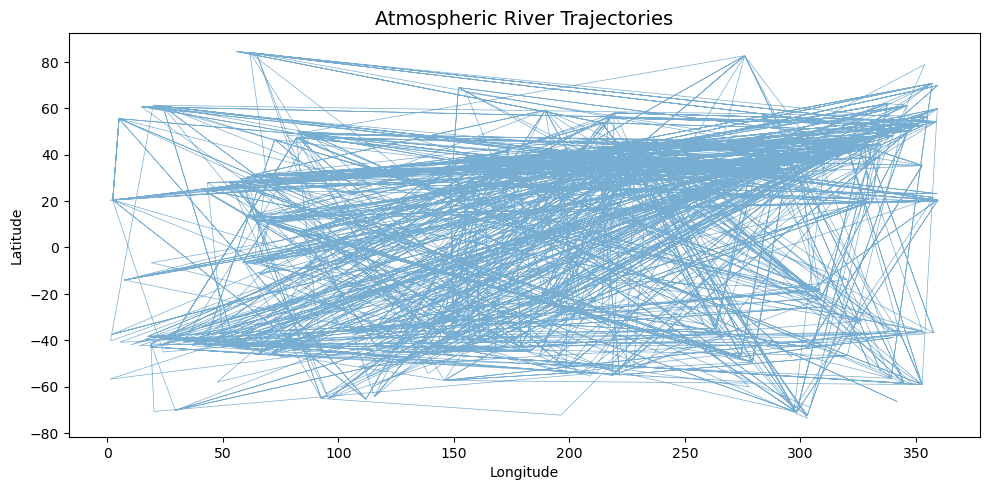

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

# Plot trajectories
gdf_lines.iloc[0:1].plot(
    ax=ax,
    linewidth=0.5,
    alpha=0.6,
)

ax.set_title("Atmospheric River Trajectories", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()


In [ ]:
# Set up projection
datacrs = ccrs.PlateCarree()  ## the projection the data is in
mapcrs = ccrs.PlateCarree() ## the projection you want your map displayed in

# Set tick/grid locations
ext1 = [-130, -100, 20, 50.] # intwest ext
dx = np.arange(-113., -105.,1)
dy = np.arange(36, 42,1)

# Create figure
fig = plt.figure(figsize=(6., 4.5))
fig.dpi = 300
fname = path_to_figs + 'AR_trajs'
fmt = 'png'

# Grid layout
gs = GridSpec(
    1,
    2,
    height_ratios=[1],
    width_ratios=[1, 0.05],
    wspace=0.15,
    hspace=0.03,
)

# Add color bar axis
cbax = fig.add_subplot(gs[0,-1])

## Add axis for plot
ax = fig.add_subplot(gs[0,0], projection=mapcrs)
ax = draw_basemap(ax, extent=ext1, xticks=dx, yticks=dy,left_lats=True, right_lats=False, bottom_lons=True, mask_ocean=False, coastline=False)

# topo with gray shading
cs = plot_terrain(ax, ext1, vmax=4400, greyscale=False)

gdf_lines.plot(
    ax=ax,
    linewidth=0.4,
    alpha=0.5,
    color="tab:blue",
    zorder=101,
    transform=ccrs.PlateCarree()   # ← THIS IS THE KEY
)

# cbar = plt.colorbar(sc, cax=cbax)
# cbar.set_label("Fraction of top-decile SWE (%)")
# cbar.set_ticks(cbarticks)

ax.add_feature(cfeature.STATES, edgecolor='0.4', linewidth=0.8, zorder=199)

        
fig.savefig('%s.%s' %(fname, fmt), bbox_inches='tight', dpi=fig.dpi)